In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── Reproductibilité ─────────────────────────────────────────────────────────
np.random.seed(42)

# ── Graphiques ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.dpi': 120,
    'figure.facecolor': 'white',
})

print("✅ Imports OK")

✅ Imports OK


In [2]:
# ── Racine du projet ─────────────────────────────────────────────────────────
ROOT = "/home/boussif/boussif/SEA-AD/MTG_scATAC"

# ── Pseudobulk RNA (raw counts, genes × donors) ──────────────────────────────
PB_PATHS = {
    "Gaba": f"{ROOT}/data/processed/pseudobulk_RNA_Gaba.csv",
    "Glu":  f"{ROOT}/data/processed/pseudobulk_RNA_Glu.csv",
}

# ── Métadonnées PPS par donneur ───────────────────────────────────────────────
META_PATH = f"{ROOT}/data/metadata/metadata_RNA_PPS.csv"

# ── Master Tables ATAC (par type cellulaire × threshold) ─────────────────────
MASTER_TABLE_PATHS = {
    "Gaba": {
        bg: f"{ROOT}/data/raw/SEA-AD/MTG_scRNA/results_aCM_AD_Gaba/Master_Table_bg{bg}.csv"
        for bg in ["1.5", "2", "3", "4"]
    },
    "Glu": {
        bg: f"{ROOT}/data/raw/SEA-AD/MTG_scRNA/results_aCM_AD_Glu/Master_Table_bg{bg}.csv"
        for bg in ["1.5", "2", "3", "4"]
    },
}

# ── Répertoire de sortie des figures ─────────────────────────────────────────
OUT_DIR = f"{ROOT}/data/processed/results_fisher_validation"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Paramètres d'analyse ─────────────────────────────────────────────────────
BG_THRESHOLDS   = ["1.5", "2", "3", "4"]   # niveaux de threshold ATAC
CELL_TYPES      = ["Gaba", "Glu"]
FISHER_TOP_FRAC = 0.10                       # top 10 % de la DE RNA pour le Fisher
MIN_DONOR_FRAC  = 0.20                       # min fraction de donneurs > seuil (filtre bg)
ATAC_FDR_CUT    = 0.05                       # seuil FDR côté ATAC-RNA

print("✅ Chemins configurés")
for ct in CELL_TYPES:
    print(f"  {ct} pseudobulk : {PB_PATHS[ct]}")
print(f"  Métadonnées PPS : {META_PATH}")
print(f"  Output          : {OUT_DIR}")

✅ Chemins configurés
  Gaba pseudobulk : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/pseudobulk_RNA_Gaba.csv
  Glu pseudobulk : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/pseudobulk_RNA_Glu.csv
  Métadonnées PPS : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/metadata/metadata_RNA_PPS.csv
  Output          : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation


In [3]:
# ── Chargement des pseudobulk RNA bruts ──────────────────────────────────────
print("Chargement des pseudobulk RNA...")
pb_raw = {}
for ct, path in PB_PATHS.items():
    pb_raw[ct] = pd.read_csv(path, index_col=0)
    print(f"  {ct} : {pb_raw[ct].shape[0]:,} gènes × {pb_raw[ct].shape[1]} donneurs")

# ── Métadonnées PPS ───────────────────────────────────────────────────────────
meta = pd.read_csv(META_PATH).dropna(subset=["Continuous Pseudo-progression Score"])
meta = meta.drop_duplicates(subset=["Donor ID"]).set_index("Donor ID")
print(f"\nMétadonnées PPS : {len(meta)} donneurs avec PPS valide")

# ── Normalisation CPM + log1p  ────────────────────────────────────────────────
# et alignement strict donneur (intersection pseudobulk ∩ PPS)
pb_logcpm = {}

for ct, raw in pb_raw.items():
    # Intersection donneurs
    common_donors = [d for d in raw.columns if d in meta.index]
    raw_sub = raw[common_donors]

    # CPM + log1p
    cpm = raw_sub.div(raw_sub.sum(axis=0), axis=1) * 1e6
    pb_logcpm[ct] = np.log1p(cpm)

    print(f"\n{ct} — donneurs retenus : {len(common_donors)}")
    print(f"  Matrice logCPM : {pb_logcpm[ct].shape}")

print("\n✅ Matrices normalisées prêtes")

Chargement des pseudobulk RNA...
  Gaba : 36,601 gènes × 84 donneurs
  Glu : 36,601 gènes × 84 donneurs

Métadonnées PPS : 84 donneurs avec PPS valide

Gaba — donneurs retenus : 84
  Matrice logCPM : (36601, 84)

Glu — donneurs retenus : 84
  Matrice logCPM : (36601, 84)

✅ Matrices normalisées prêtes


In [4]:
def compute_rna_pps_corr(pb_logcpm_sub, pps_values, bg_threshold):
    """
    Filtre les gènes selon le seuil d'expression `bg_threshold` (logCPM),
    puis calcule la corrélation Spearman de chaque gène avec le PPS.

    Paramètres
    ----------
    pb_logcpm_sub : DataFrame  (genes × donors)
    pps_values    : array-like  (aligned with pb_logcpm_sub columns)
    bg_threshold  : float  — seuil de filtrage en logCPM

    Retourne
    --------
    res_de   : DataFrame  (gene → r, pval, fdr) trié par pval
    bg_genes : list de gènes passant le filtre
    """
    n_donors = pb_logcpm_sub.shape[1]
    min_donors = int(n_donors * MIN_DONOR_FRAC)

    # Filtre expression : logCPM > threshold chez ≥ MIN_DONOR_FRAC donneurs
    expr_mask = (pb_logcpm_sub > float(bg_threshold)).sum(axis=1) >= min_donors
    bg_genes  = pb_logcpm_sub.index[expr_mask].tolist()

    # Corrélation Spearman gène par gène
    results = []
    for gene in bg_genes:
        expr = pb_logcpm_sub.loc[gene].values
        r, pval = stats.spearmanr(expr, pps_values)
        results.append({"gene": gene, "r": r, "pval": pval})

    res_de = pd.DataFrame(results).set_index("gene").dropna()
    res_de["fdr"] = multipletests(res_de["pval"], method="fdr_bh")[1]
    res_de = res_de.sort_values("pval")

    return res_de, bg_genes


print("✅ Fonction compute_rna_pps_corr définie")

✅ Fonction compute_rna_pps_corr définie


In [5]:
print("Calcul des corrélations RNA~PPS par type cellulaire et threshold...")
print("(~1-3 min selon la taille du background)\n")

# Stockage de tous les résultats DE
de_results = {}   # de_results[ct][bg] = (res_de DataFrame, pps_values array)

for ct in CELL_TYPES:
    de_results[ct] = {}
    mat = pb_logcpm[ct]

    # PPS aligné sur les donneurs de cette matrice
    common_donors = mat.columns.tolist()
    pps_vals = meta.loc[common_donors, "Continuous Pseudo-progression Score"].values

    for bg in BG_THRESHOLDS:
        print(f"  ⏳ {ct} bg{bg} ...", end=" ", flush=True)
        res_de, bg_genes = compute_rna_pps_corr(mat, pps_vals, bg)
        de_results[ct][bg] = (res_de, pps_vals, bg_genes)
        sig = (res_de["fdr"] < 0.05).sum()
        print(f"{len(bg_genes):,} gènes background → {len(res_de):,} testés → {sig:,} FDR<0.05")

print("\n✅ Corrélations terminées")

Calcul des corrélations RNA~PPS par type cellulaire et threshold...
(~1-3 min selon la taille du background)

  ⏳ Gaba bg1.5 ... 16,861 gènes background → 16,861 testés → 8,497 FDR<0.05
  ⏳ Gaba bg2 ... 14,663 gènes background → 14,663 testés → 7,357 FDR<0.05
  ⏳ Gaba bg3 ... 10,345 gènes background → 10,345 testés → 5,338 FDR<0.05
  ⏳ Gaba bg4 ... 5,817 gènes background → 5,817 testés → 3,043 FDR<0.05
  ⏳ Glu bg1.5 ... 17,137 gènes background → 17,137 testés → 8,365 FDR<0.05
  ⏳ Glu bg2 ... 14,861 gènes background → 14,861 testés → 7,160 FDR<0.05
  ⏳ Glu bg3 ... 10,529 gènes background → 10,529 testés → 5,023 FDR<0.05
  ⏳ Glu bg4 ... 5,890 gènes background → 5,890 testés → 2,800 FDR<0.05

✅ Corrélations terminées


In [6]:
def run_fisher_test(res_de, genes_hits_atac, top_frac=FISHER_TOP_FRAC):
    """
    Test de Fisher (enrichissement unilatéral 'greater') des gènes ATAC
    parmi le top `top_frac` de la DE RNA.

    Retourne un dict avec les métriques clés.
    """
    background_genes = res_de.index.tolist()
    n_bg = len(background_genes)

    # Top RNA par rang de p-value
    top_k = max(1, int(n_bg * top_frac))
    res_de_ranked = res_de.copy()
    res_de_ranked["rank"] = res_de_ranked["pval"].rank(method="min")
    genes_top_rna = set(res_de_ranked[res_de_ranked["rank"] <= top_k].index)

    # Restreindre les hits ATAC au background RNA (gènes communs)
    atac_in_bg = [g for g in genes_hits_atac if g in background_genes]
    atac_set   = set(atac_in_bg)

    # Table de contingence 2×2
    #                  | Top RNA | Not Top RNA |
    # Hit ATAC         |   A     |      B      |
    # Non-Hit ATAC     |   C     |      D      |
    A = len(atac_set & genes_top_rna)
    B = len(atac_set) - A
    C = len(genes_top_rna) - A
    D = n_bg - A - B - C

    contingency = [[A, B], [C, D]]
    odds_ratio, p_fisher = stats.fisher_exact(contingency, alternative="greater")

    return {
        "n_background"    : n_bg,
        "n_top_rna"       : len(genes_top_rna),
        "n_atac_in_bg"    : len(atac_in_bg),
        "n_atac_top"      : A,
        "odds_ratio"      : odds_ratio,
        "p_fisher"        : p_fisher,
        "contingency"     : contingency,
        "genes_top_rna"   : genes_top_rna,
        "atac_in_bg"      : atac_in_bg,
    }


print("✅ Fonction run_fisher_test définie")

✅ Fonction run_fisher_test définie


In [7]:
print("=" * 65)
print("  TEST DE FISHER — Gaba & Glu × bg1.5 / bg2 / bg3 / bg4")
print("=" * 65)

fisher_results = {}   # fisher_results[ct][bg] = dict

rows_summary = []

for ct in CELL_TYPES:
    fisher_results[ct] = {}
    print(f"\n{'─'*55}")
    print(f"  Type cellulaire : {ct.upper()}")
    print(f"{'─'*55}")

    for bg in BG_THRESHOLDS:
        res_de, _, _ = de_results[ct][bg]

        # Chargement du Master Table ATAC
        mt_path = MASTER_TABLE_PATHS[ct][bg]
        try:
            df_mt = pd.read_csv(mt_path)
            # Gènes significatifs en ATAC-RNA (FDR < seuil)
            genes_atac = df_mt[df_mt["fdr_atac_rna"] < ATAC_FDR_CUT]["gene"].dropna().unique().tolist()
        except Exception as e:
            print(f"  ⚠️  bg{bg} — Master Table introuvable : {e}")
            genes_atac = []

        if len(genes_atac) == 0:
            print(f"  bg{bg} — Aucun gène ATAC significatif, skip.")
            continue

        fr = run_fisher_test(res_de, genes_atac)
        fisher_results[ct][bg] = fr

        sig_label = "✅ SIGNIFICATIF" if fr["p_fisher"] < 0.05 else "⚠️  non-sig"
        print(f"\n  bg{bg}  —  {sig_label}")
        print(f"    Background RNA total     : {fr['n_background']:,}")
        print(f"    Gènes Top {int(FISHER_TOP_FRAC*100):2d}% RNA       : {fr['n_top_rna']:,}")
        print(f"    Gènes ATAC (FDR<{ATAC_FDR_CUT}) : {fr['n_atac_in_bg']:,} dans le background")
        print(f"    Overlap (ATAC ∩ Top RNA) : {fr['n_atac_top']:,}")
        print(f"    Odds Ratio               : {fr['odds_ratio']:.2f}x")
        print(f"    p-value Fisher           : {fr['p_fisher']:.2e}")

        # Table de contingence
        ctg = fr["contingency"]
        df_ctg = pd.DataFrame(ctg,
                              columns=["Dans Top RNA", "Pas Top RNA"],
                              index=["Hit ATAC", "Pas Hit ATAC"])
        display(df_ctg)

        rows_summary.append({
            "cell_type"    : ct,
            "bg"           : bg,
            "n_background" : fr["n_background"],
            "n_top_rna"    : fr["n_top_rna"],
            "n_atac"       : fr["n_atac_in_bg"],
            "overlap"      : fr["n_atac_top"],
            "odds_ratio"   : round(fr["odds_ratio"], 3),
            "p_fisher"     : fr["p_fisher"],
            "significant"  : fr["p_fisher"] < 0.05,
        })

# Tableau récapitulatif
print("\n" + "=" * 65)
print("  RÉCAPITULATIF")
print("=" * 65)
df_summary = pd.DataFrame(rows_summary)
display(df_summary)

  TEST DE FISHER — Gaba & Glu × bg1.5 / bg2 / bg3 / bg4

───────────────────────────────────────────────────────
  Type cellulaire : GABA
───────────────────────────────────────────────────────



  bg1.5  —  ✅ SIGNIFICATIF
    Background RNA total     : 16,861
    Gènes Top 10% RNA       : 1,686
    Gènes ATAC (FDR<0.05) : 4,544 dans le background
    Overlap (ATAC ∩ Top RNA) : 666
    Odds Ratio               : 1.90x
    p-value Fisher           : 1.90e-32


,Dans Top RNA,Pas Top RNA
Hit ATAC,666,3878
Pas Hit ATAC,1020,11297



  bg2  —  ✅ SIGNIFICATIF
    Background RNA total     : 14,663
    Gènes Top 10% RNA       : 1,466
    Gènes ATAC (FDR<0.05) : 2,273 dans le background
    Overlap (ATAC ∩ Top RNA) : 333
    Odds Ratio               : 1.71x
    p-value Fisher           : 1.07e-14


,Dans Top RNA,Pas Top RNA
Hit ATAC,333,1940
Pas Hit ATAC,1133,11257


...

,Dans Top RNA,Pas Top RNA
Hit ATAC,215,1198
Pas Hit ATAC,837,8279



  bg4  —  ✅ SIGNIFICATIF
    Background RNA total     : 5,890
    Gènes Top 10% RNA       : 589
    Gènes ATAC (FDR<0.05) : 658 dans le background
    Overlap (ATAC ∩ Top RNA) : 99
    Odds Ratio               : 1.71x
    p-value Fisher           : 9.24e-06


,Dans Top RNA,Pas Top RNA
Hit ATAC,99,559
Pas Hit ATAC,490,4742



  RÉCAPITULATIF


,cell_type,bg,n_background,n_top_rna,n_atac,overlap,odds_ratio,p_fisher,significant
0,Gaba,1.5,16861,1686,4544,666,1.902,1.896404e-32,True
1,Gaba,2,14663,1466,2273,333,1.705,1.074876e-14,True
2,Gaba,3,10345,1034,841,119,1.547,3.927863e-05,True
3,Gaba,4,5817,581,344,50,1.583,3.658707e-03,True
4,Glu,1.5,17137,1713,6486,888,1.889,1.752777e-35,True
5,Glu,2,14861,1486,3541,503,1.741,1.821725e-20,True
6,Glu,3,10529,1052,1413,215,1.775,1.692621e-11,True
7,Glu,4,5890,589,658,99,1.714,9.238172e-06,True


In [8]:
print("=" * 65)
print("  GOLDEN GENES — Top 10% |r| RNA ∩ Hits ATAC")
print("  (séparés par type cellulaire et threshold)")
print("=" * 65)

# Stockage pour la visualisation ultérieure
golden_genes_repo = {}   # golden_genes_repo[ct][bg] = {gene: r}

for ct in CELL_TYPES:
    golden_genes_repo[ct] = {}
    print(f"\n{'─'*55}")
    print(f"  {ct.upper()}")
    print(f"{'─'*55}")

    for bg in BG_THRESHOLDS:
        if bg not in fisher_results.get(ct, {}):
            continue

        res_de      = de_results[ct][bg][0]
        fr          = fisher_results[ct][bg]
        atac_in_bg  = fr["atac_in_bg"]

        # Seuil Top 10% basé sur |r|
        top_r_thr   = res_de["r"].abs().quantile(1 - FISHER_TOP_FRAC)
        top10_genes = set(res_de[res_de["r"].abs() >= top_r_thr].index)

        # Golden Genes = top RNA ∩ ATAC significatifs
        golden = [g for g in atac_in_bg if g in top10_genes]
        golden_genes_repo[ct][bg] = {
            g: res_de.loc[g, "r"] for g in golden if g in res_de.index
        }

        print(f"\n  bg{bg}  —  seuil |r| ≥ {top_r_thr:.3f}")
        print(f"    Gènes Top 10% DE  : {len(top10_genes):,}")
        print(f"    Gènes ATAC in bg  : {len(atac_in_bg):,}")
        print(f"    🏆 Golden Genes   : {len(golden)}")
        print("    " + "─" * 40)

        # Affichage détaillé
        if golden:
            for g in sorted(golden, key=lambda x: abs(golden_genes_repo[ct][bg][x]), reverse=True):
                r_val   = res_de.loc[g, "r"]   if g in res_de.index else float("nan")
                fdr_val = res_de.loc[g, "fdr"] if g in res_de.index else float("nan")
                print(f"    {g:<25}  r={r_val:+.3f}   FDR={fdr_val:.2e}")
        else:
            print("    (aucun golden gene pour cette combinaison)")

print("\n✅ Golden Genes identifiés")

  GOLDEN GENES — Top 10% |r| RNA ∩ Hits ATAC
  (séparés par type cellulaire et threshold)

───────────────────────────────────────────────────────
  GABA
───────────────────────────────────────────────────────

  bg1.5  —  seuil |r| ≥ 0.473
    Gènes Top 10% DE  : 1,687
    Gènes ATAC in bg  : 4,544
    🏆 Golden Genes   : 666
    ────────────────────────────────────────
    RUBCNL                     r=-0.634   FDR=5.33e-07
    AC022973.3                 r=-0.627   FDR=6.51e-07
    PTPN1                      r=-0.626   FDR=6.51e-07
    OSBPL10-AS1                r=-0.616   FDR=6.51e-07
    LINC02144                  r=-0.613   FDR=6.51e-07
    LINC01844                  r=-0.613   FDR=6.51e-07
    WWP1                       r=+0.608   FDR=6.51e-07
    CADM1                      r=+0.607   FDR=6.51e-07
    UBE2L3                     r=+0.606   FDR=6.51e-07
    UNC5D                      r=+0.606   FDR=6.51e-07
    KIF3C                      r=+0.605   FDR=6.51e-07
    AL157392.2        

Corrélation des marqueurs spécifiques avec le PPS

──────────────────────────────────────────────────
  GABA
──────────────────────────────────────────────────
  GAD1         r=-0.435   p=3.54e-05 ← ⚠️
  GAD2         r=-0.144   p=1.90e-01
  SLC32A1      r=-0.292   p=7.00e-03
  PVALB        r=-0.201   p=6.62e-02
  SST          r=-0.527   p=2.65e-07 ← ⚠️
  VIP          r=-0.438   p=3.15e-05 ← ⚠️


  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Gaba_bg1.5.png


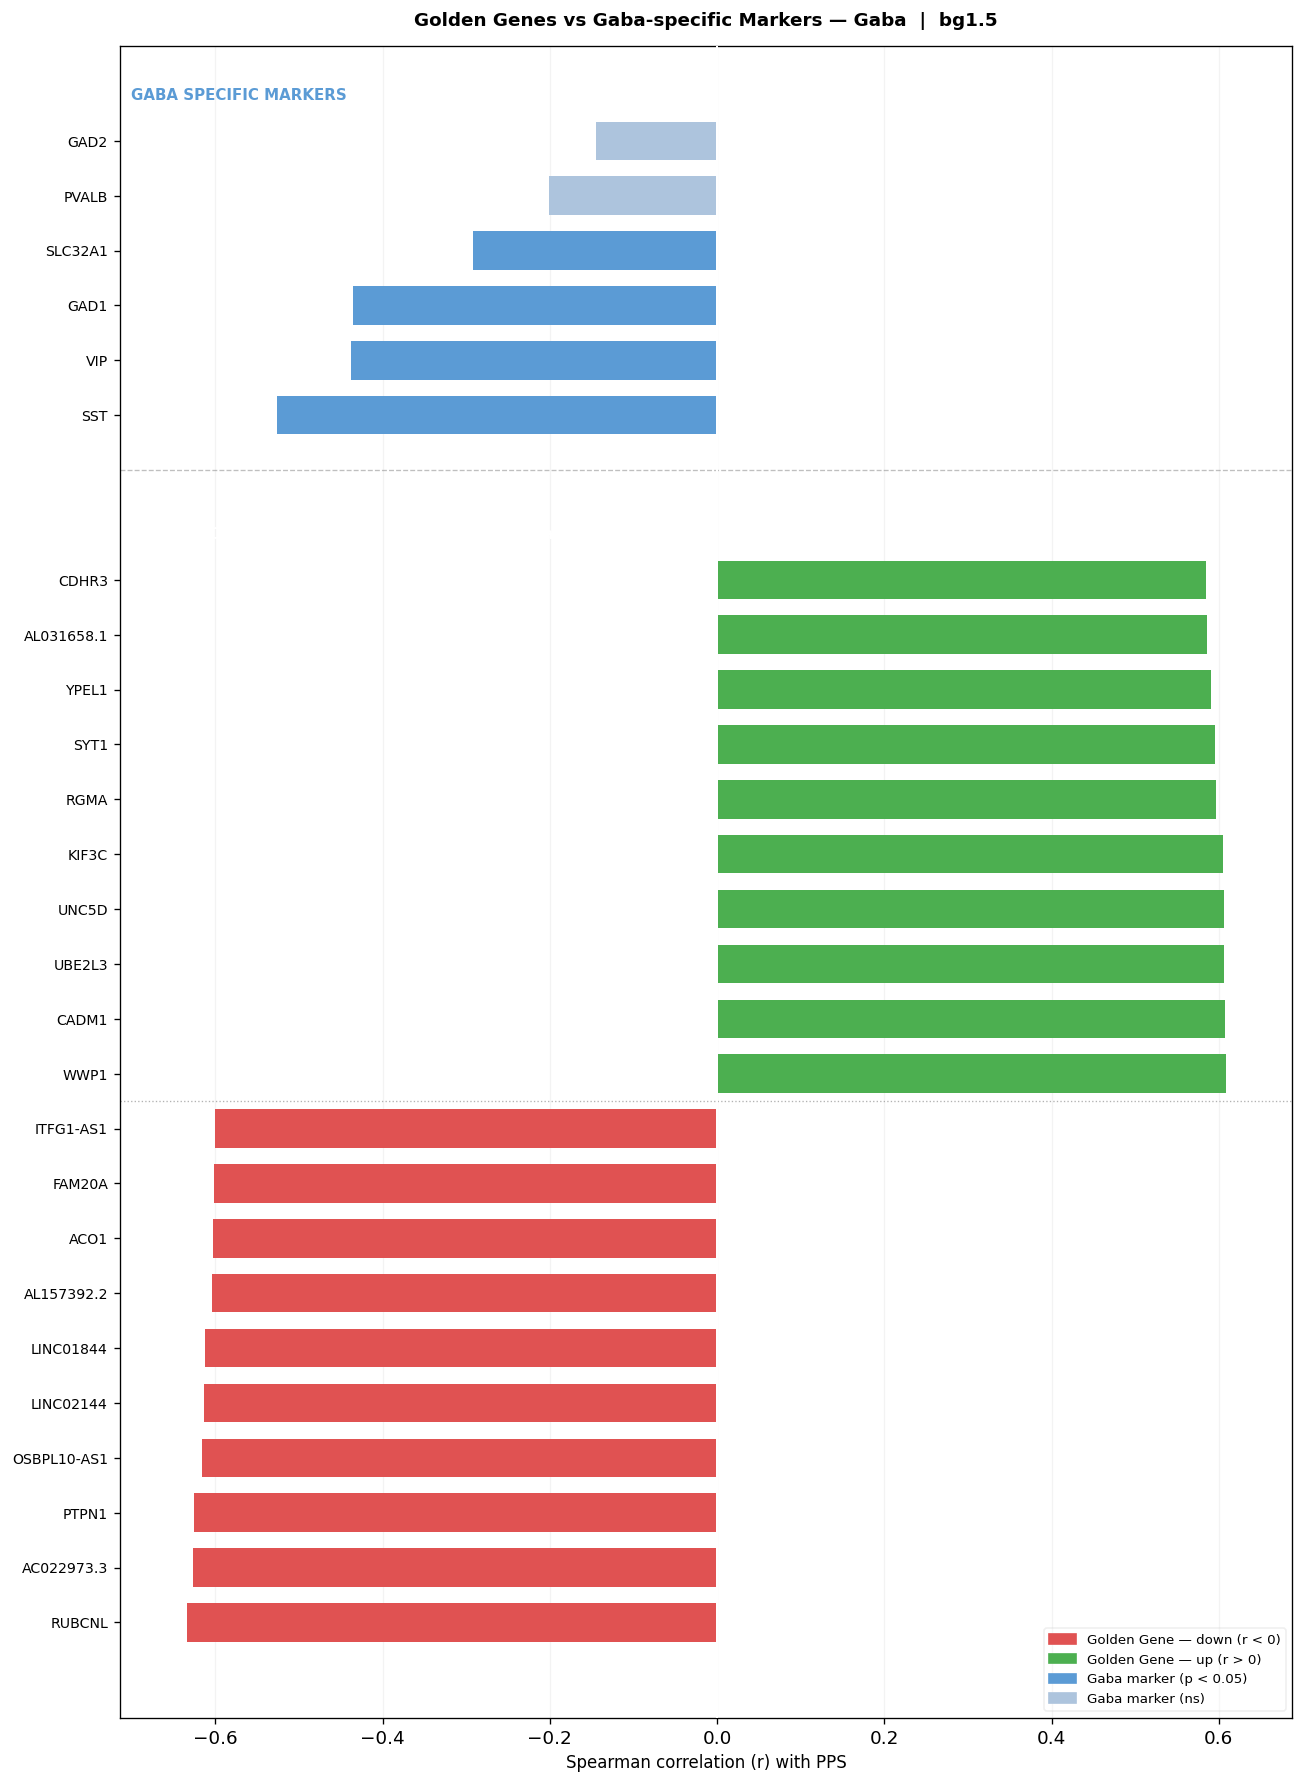

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Gaba_bg2.png


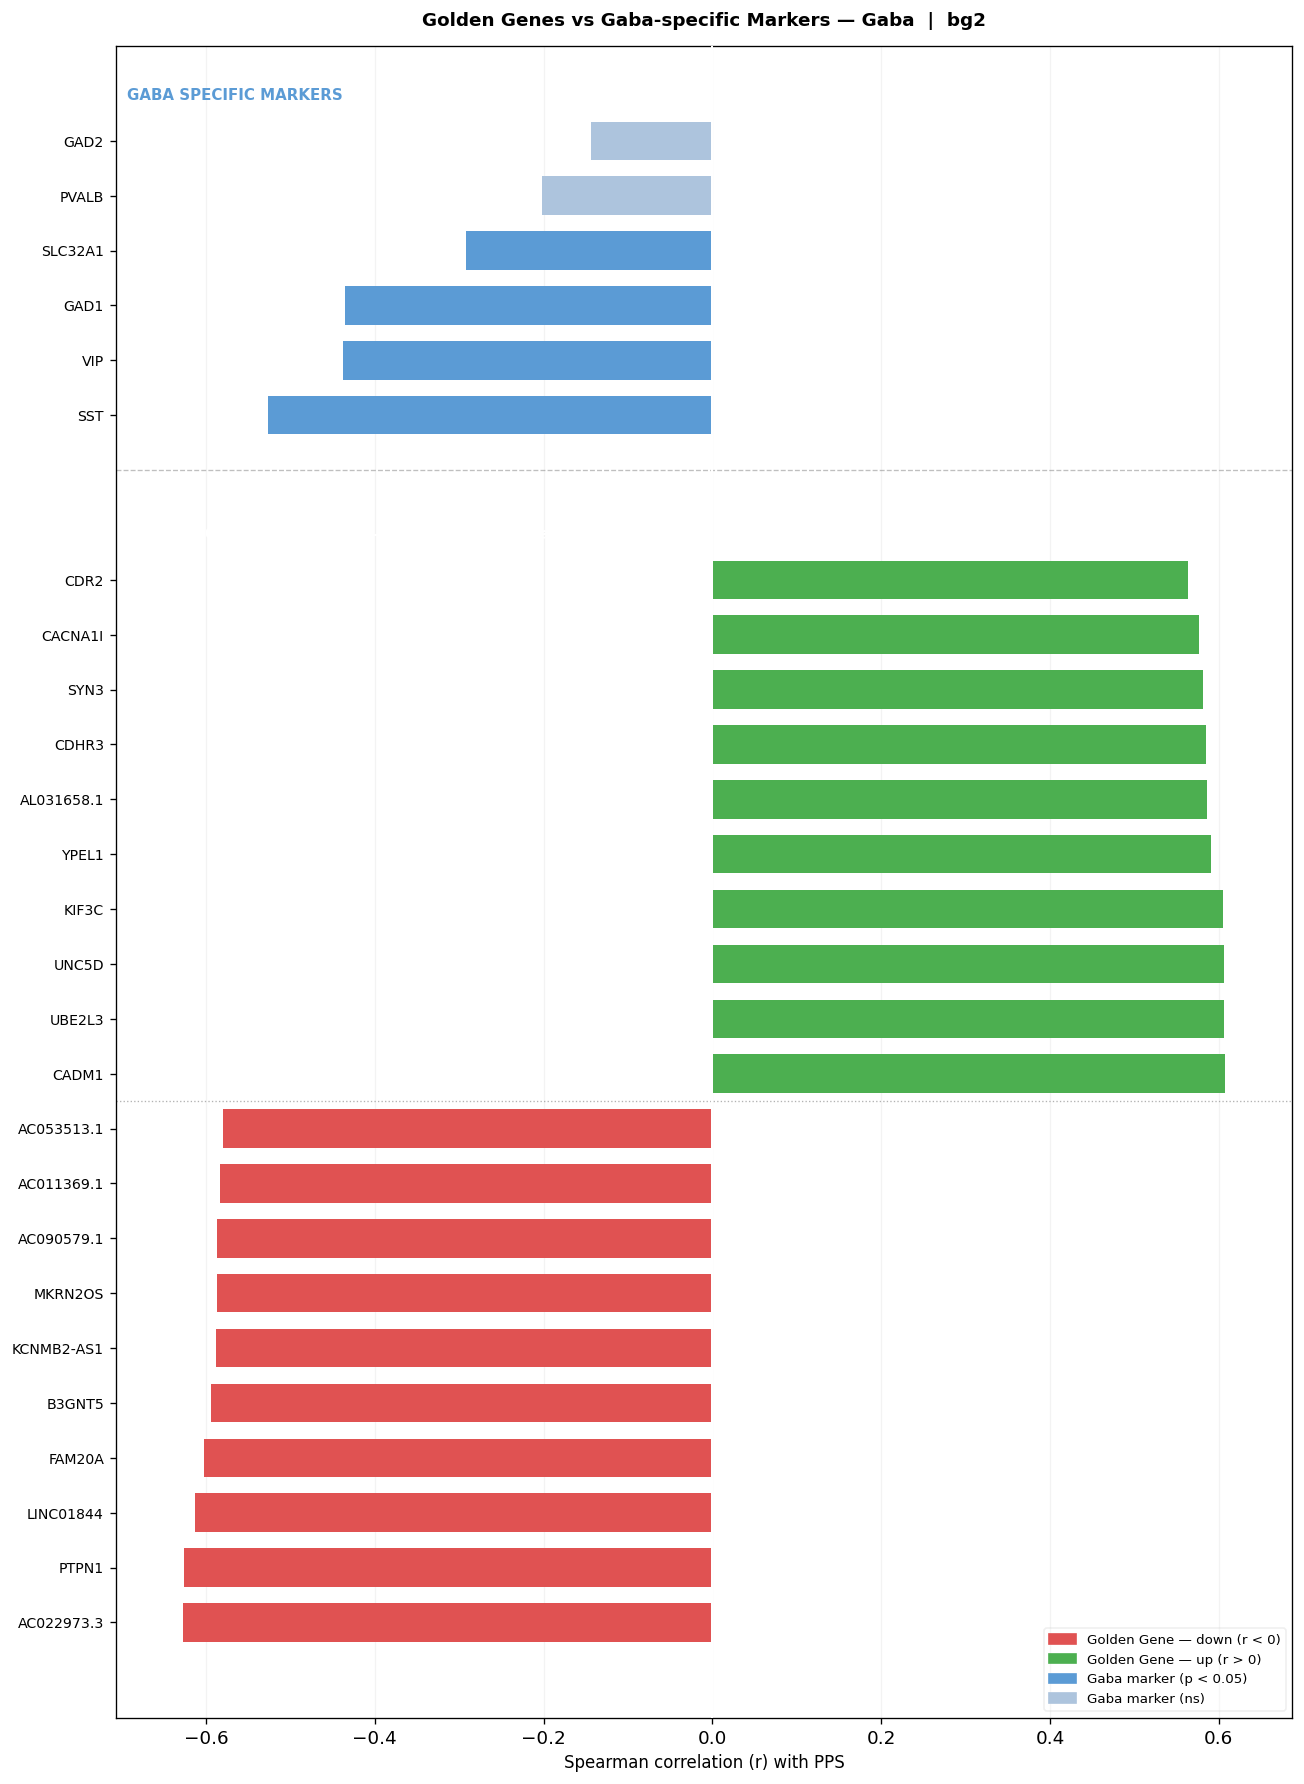

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Gaba_bg3.png


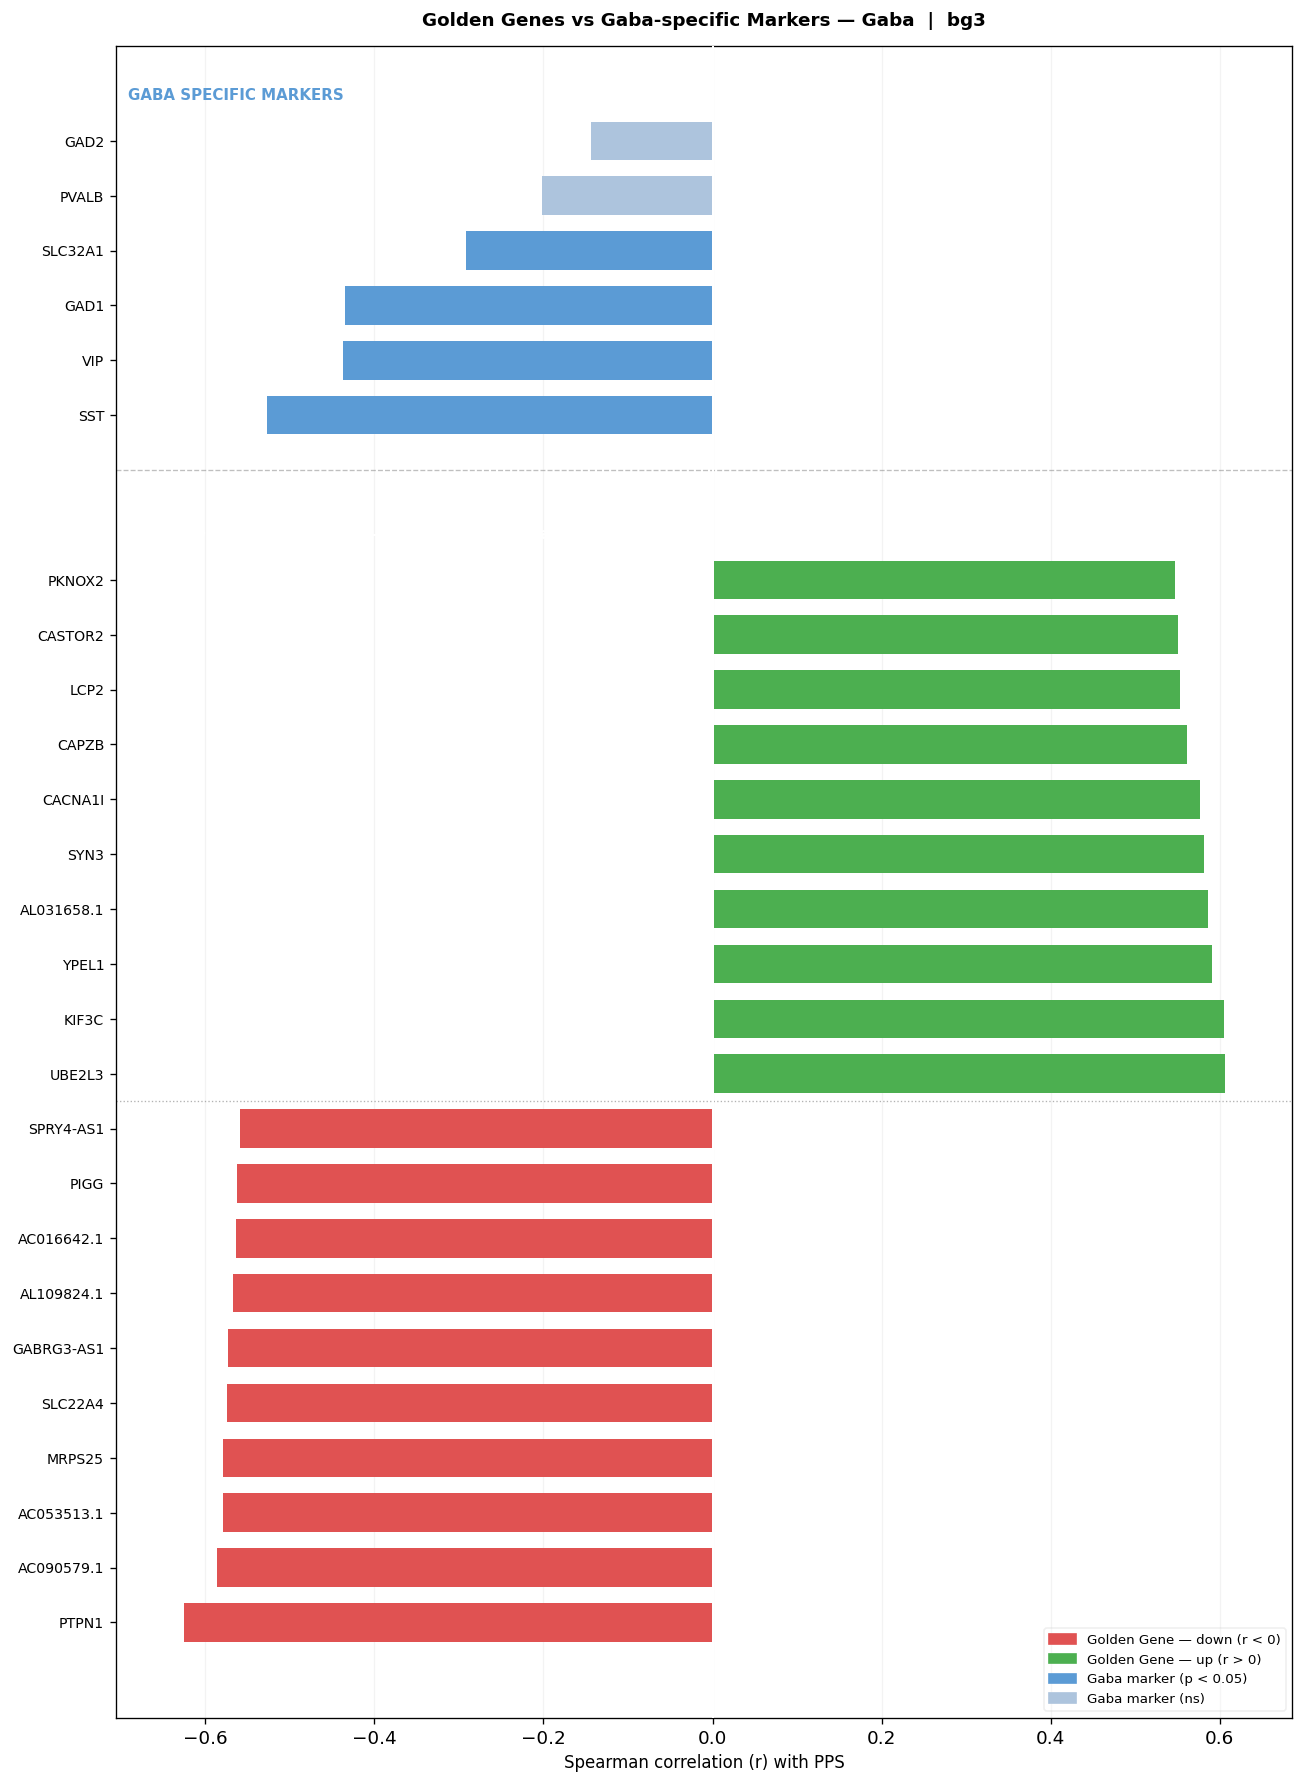

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Gaba_bg4.png


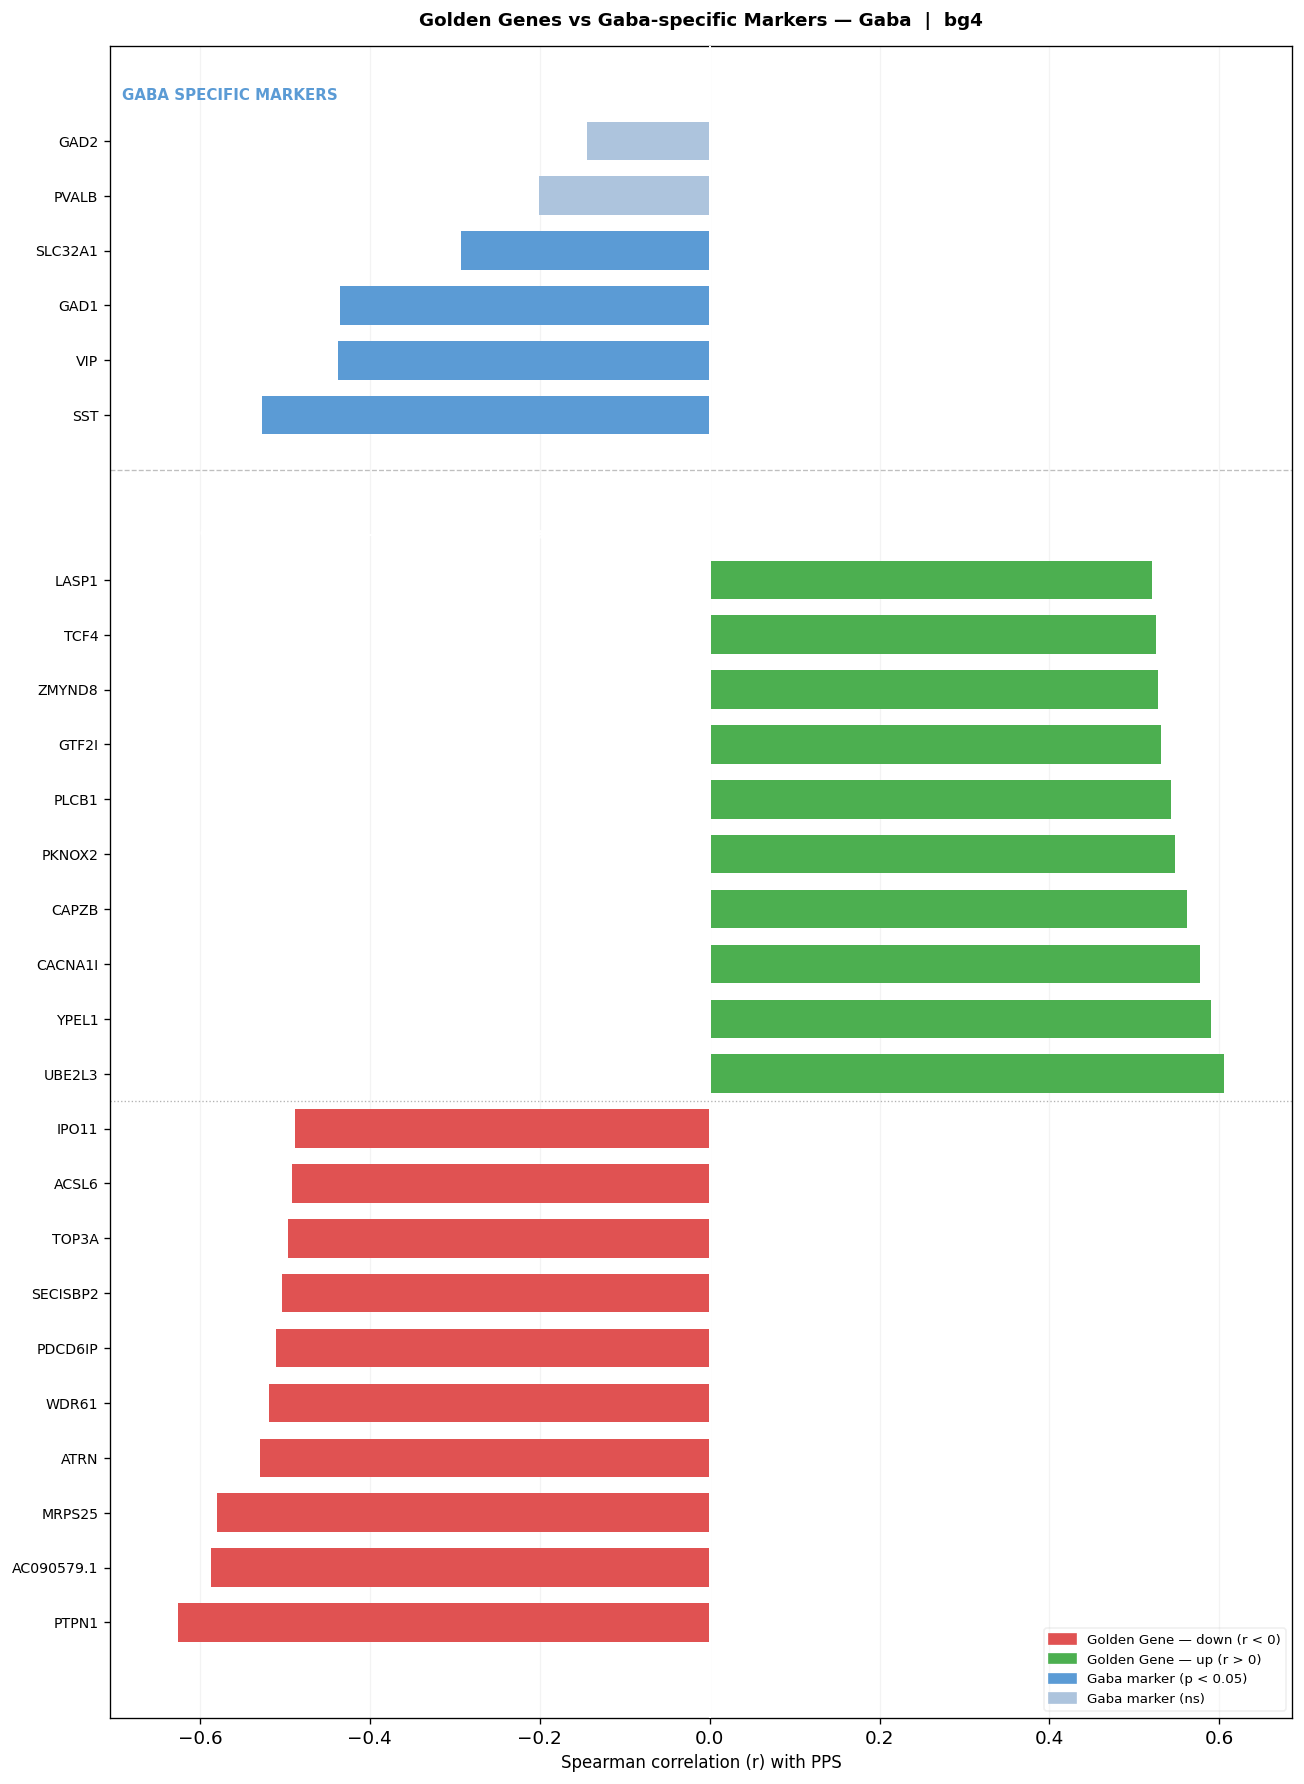

──────────────────────────────────────────────────
  GLU
──────────────────────────────────────────────────
  SLC17A7      r=+0.362   p=7.10e-04
  CAMK2A       r=+0.053   p=6.32e-01
  GRIA1        r=+0.418   p=7.64e-05 ← ⚠️
  GRIA2        r=+0.306   p=4.68e-03
  NRGN         r=+0.250   p=2.20e-02
  SATB2        r=+0.402   p=1.50e-04 ← ⚠️
  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Glu_bg1.5.png


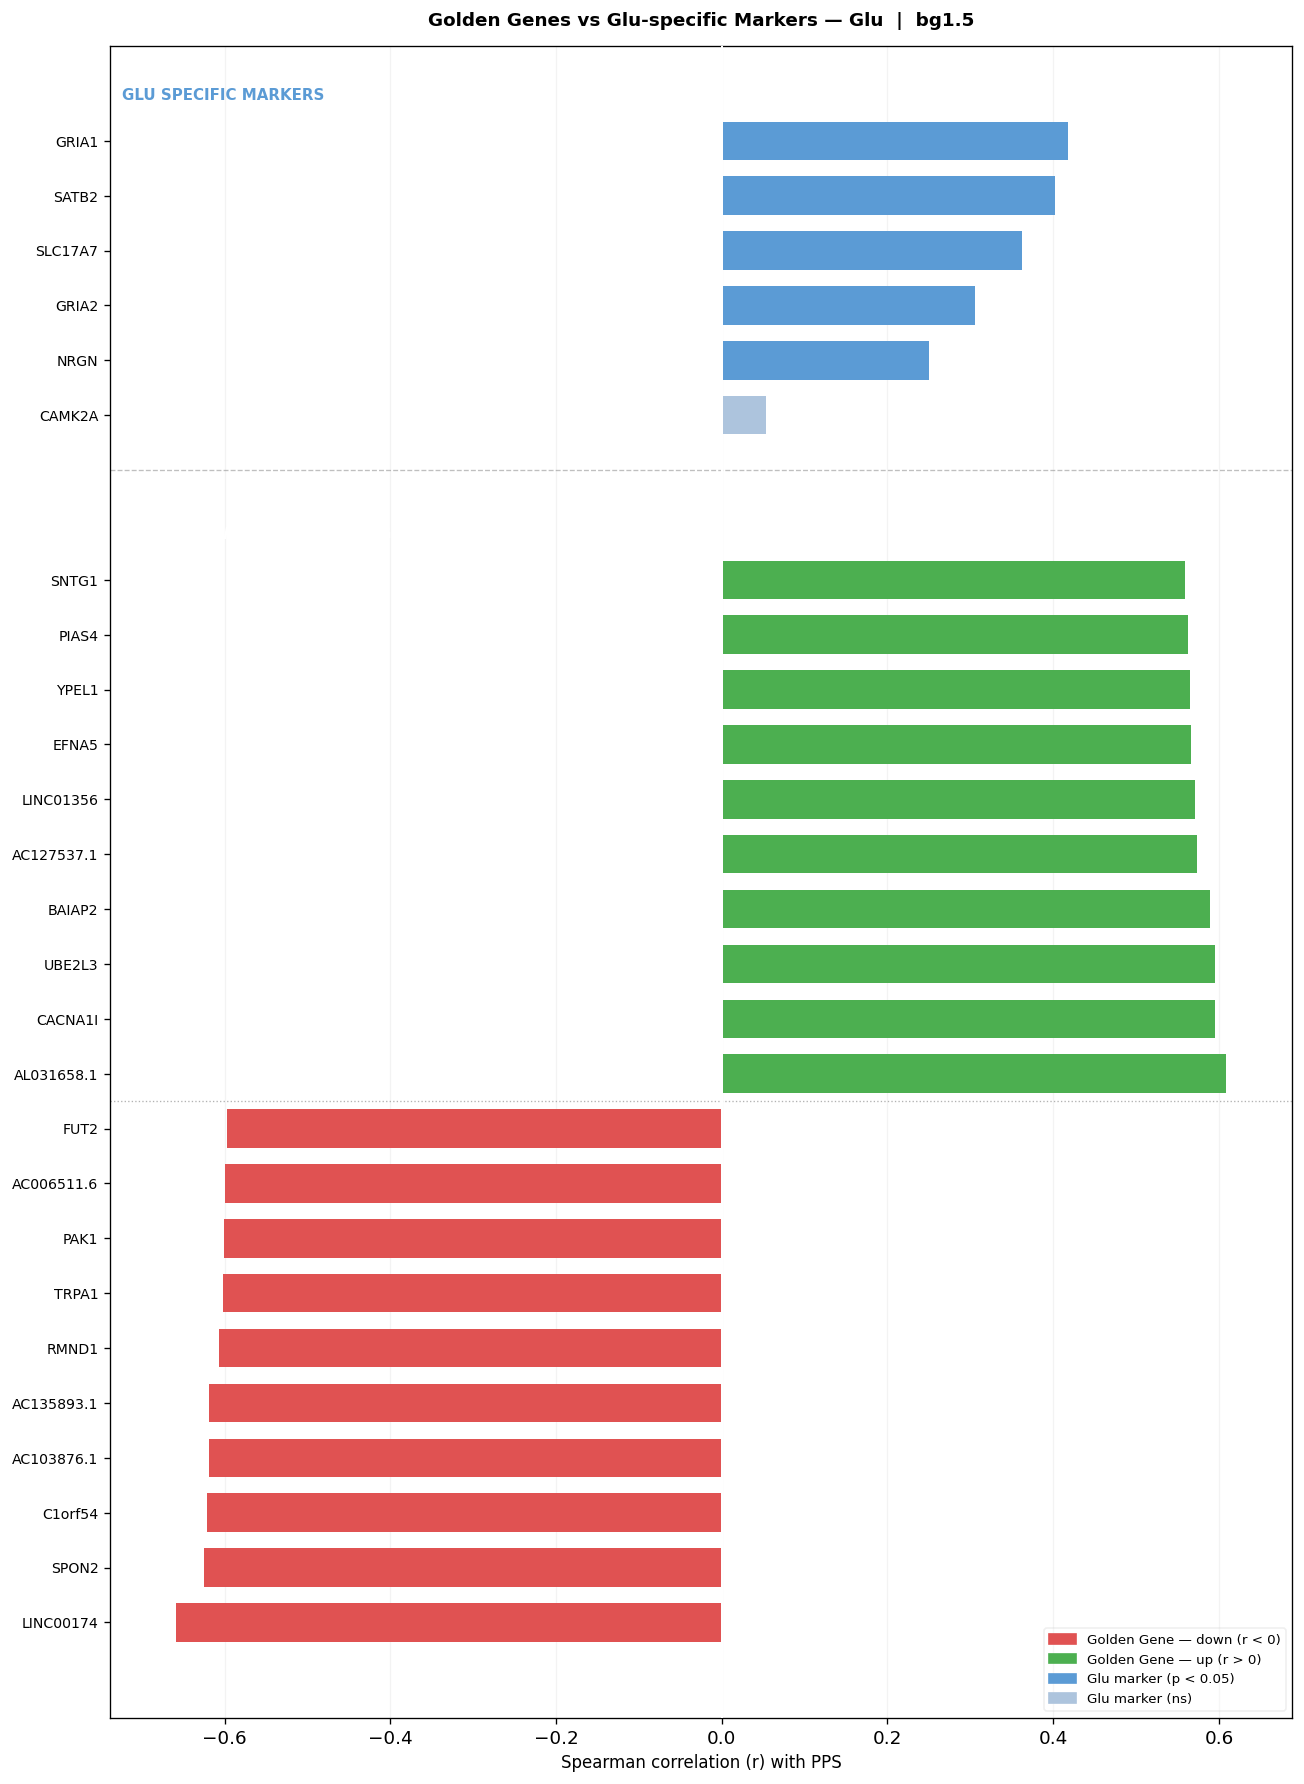

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Glu_bg2.png


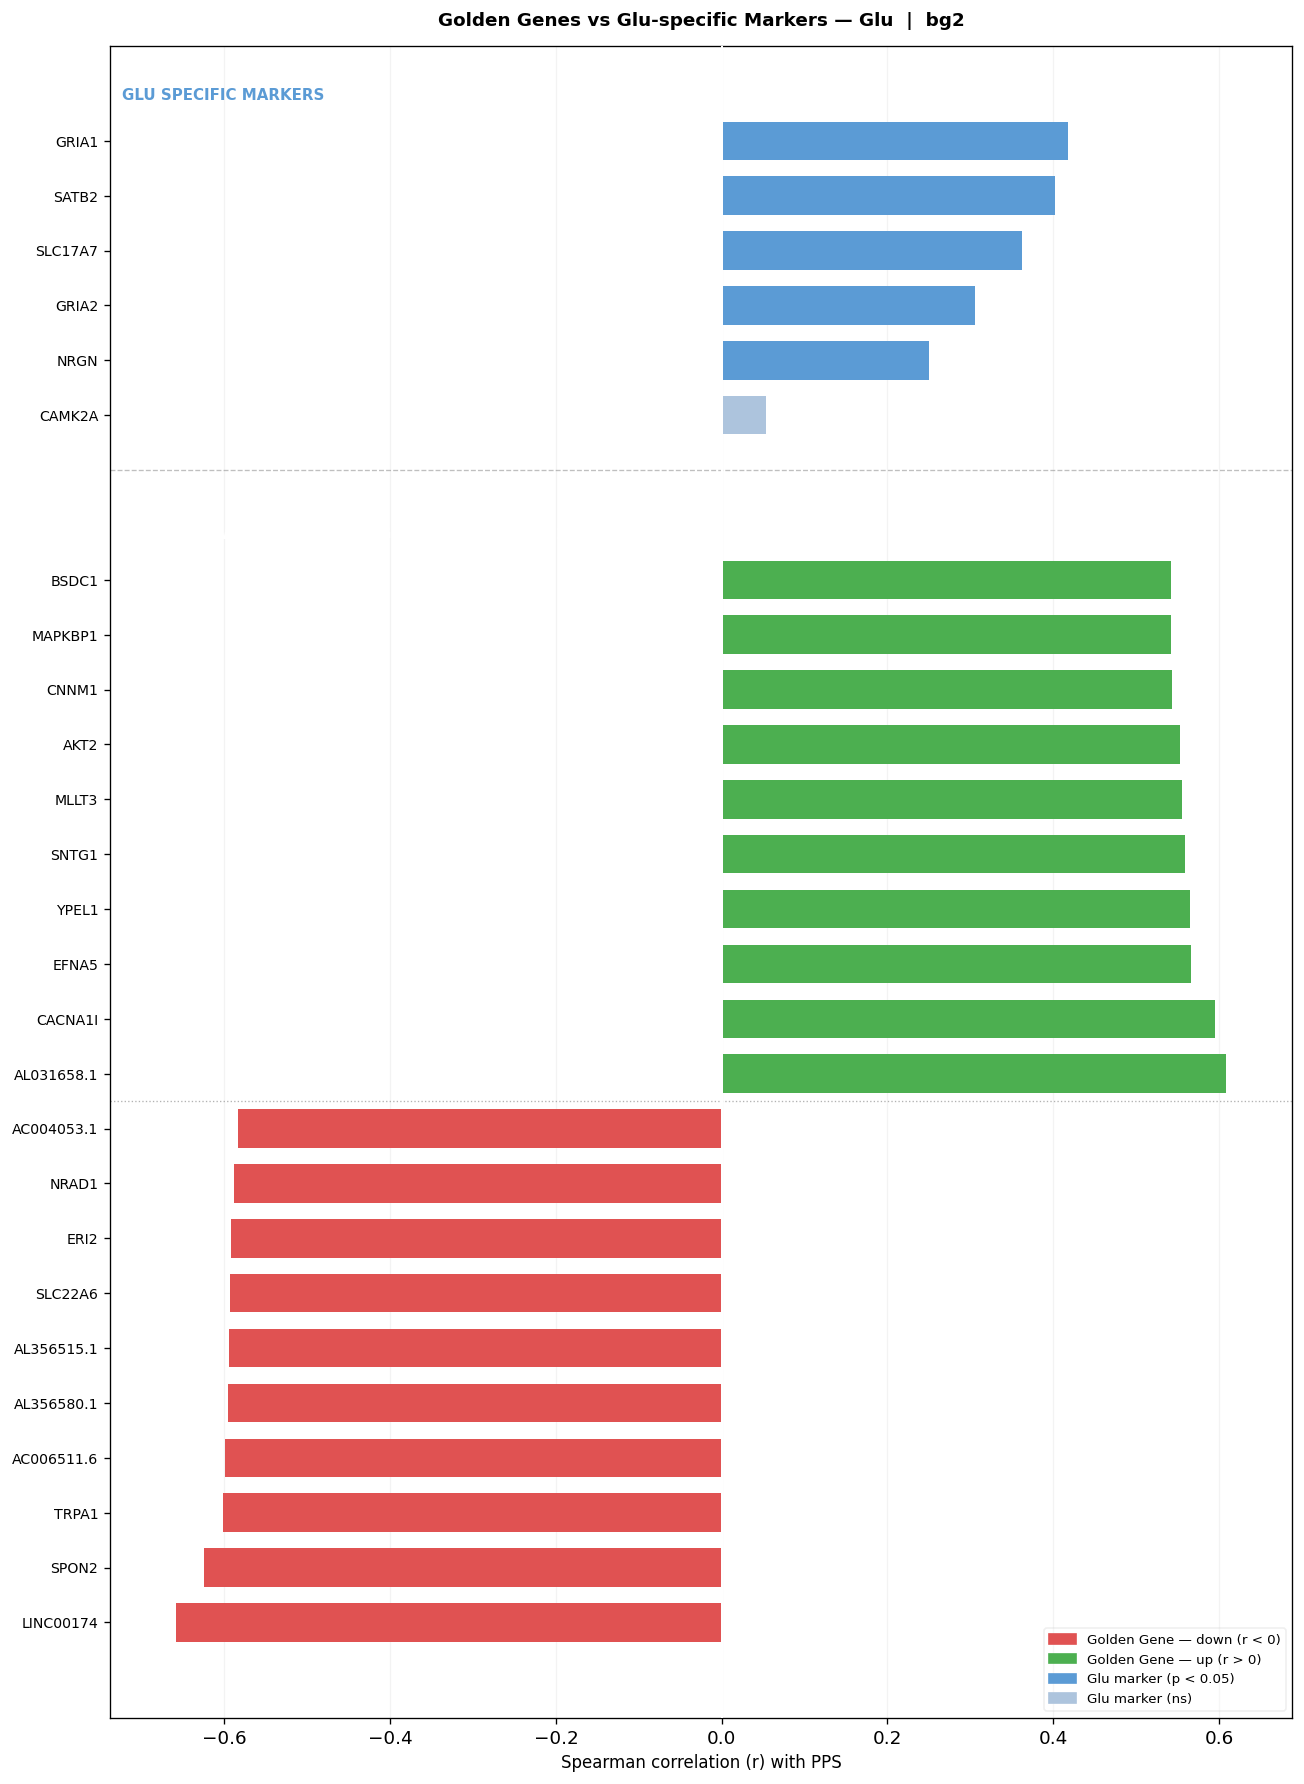

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Glu_bg3.png


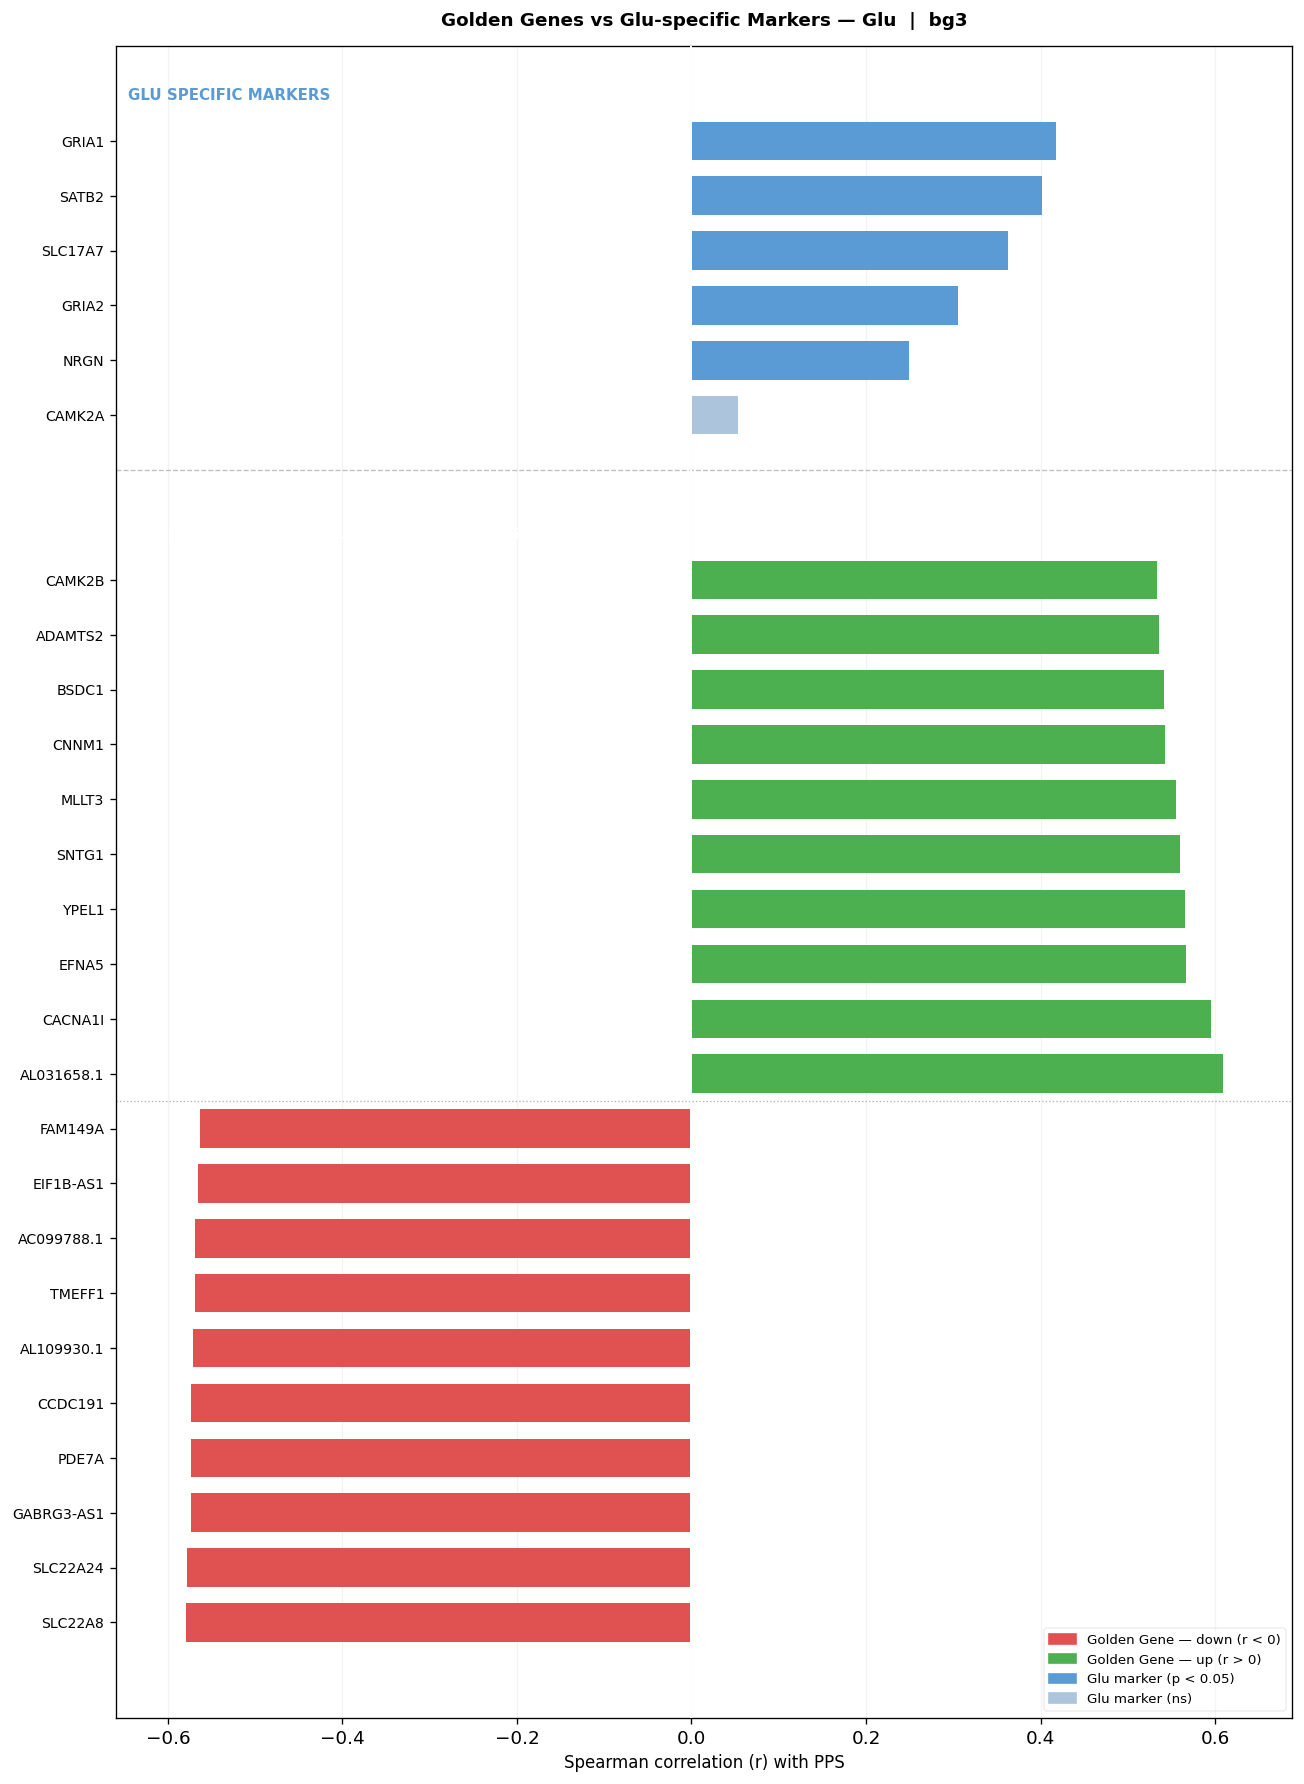

  💾 Sauvegardé : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_vs_markers_Glu_bg4.png


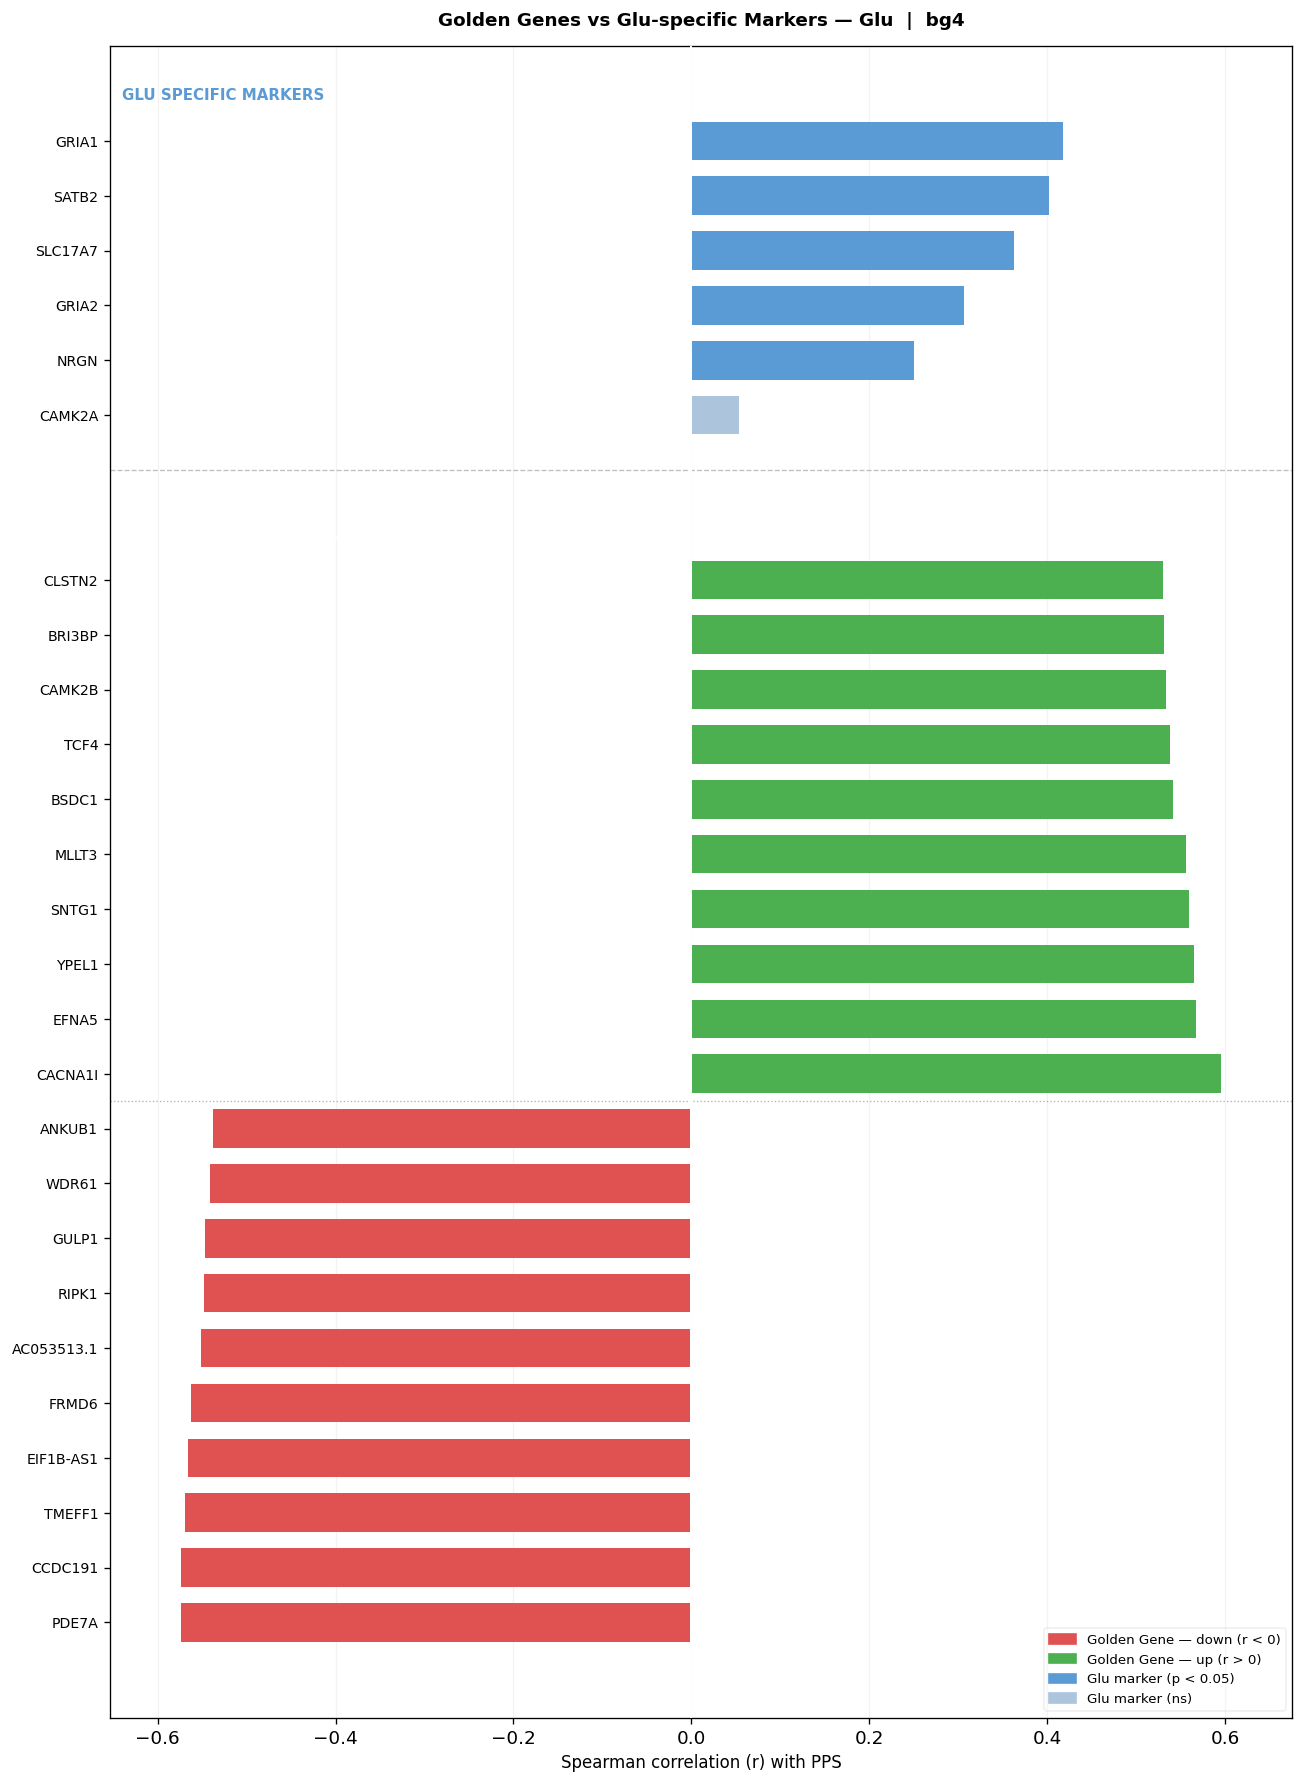

In [9]:
# Marqueurs spécifiques à chaque type cellulaire
MARKERS_BY_CT = {
    "Glu": [
        "SLC17A7",   # VGLUT1 — marqueur excitateur canonique
        "CAMK2A",    # kinase excitateur
        "GRIA1",     # récepteur AMPA
        "GRIA2",     # récepteur AMPA
        "NRGN",      # neurogranine
        "SATB2",     # TF excitateur cortical
    ],
    "Gaba": [
        "GAD1",      # glutamate décarboxylase 1
        "GAD2",      # glutamate décarboxylase 2
        "SLC32A1",   # VGAT — transporteur inhibiteur
        "PVALB",     # parvalbumine
        "SST",       # somatostatine
        "VIP",       # vasoactive intestinal peptide
    ],
}

TOP_N = 10  # top N up + top N down golden genes à afficher

def plot_golden_vs_markers_v2(ct, bg, golden_data, marker_results, save=True):
    if not golden_data:
        print(f"  {ct} bg{bg} — pas de golden genes, figure ignorée.")
        return

    # ── Top 10 up + Top 10 down parmi les golden genes ─────────────────────
    all_items  = sorted(golden_data.items(), key=lambda x: x[1])
    down_items = all_items[:TOP_N]                  # les plus négatifs
    up_items   = all_items[-(TOP_N):][::-1]         # les plus positifs
    selected   = down_items + up_items

    g_names = [x[0] for x in selected]
    g_r     = [x[1] for x in selected]

    # ── Marqueurs spécifiques au type cellulaire ────────────────────────────
    m_items  = sorted(marker_results.items(), key=lambda x: x[1][0])
    m_names  = [x[0] for x in m_items]
    m_r      = [x[1][0] for x in m_items]
    m_pval   = [x[1][1] for x in m_items]

    gap       = 2.0
    y_golden  = np.arange(len(g_names))
    y_markers = np.arange(len(g_names) + gap, len(g_names) + gap + len(m_names))

    fig, ax = plt.subplots(figsize=(11, max(7, (len(g_names) + len(m_names)) * 0.5 + 2)))

    # Golden Genes
    colors_g = ["#e05252" if r < 0 else "#4caf50" for r in g_r]
    ax.barh(y_golden, g_r, color=colors_g, height=0.7, zorder=3)

    # Marqueurs
    colors_m = ["#5b9bd5" if p < 0.05 else "#adc4dd" for p in m_pval]
    ax.barh(y_markers, m_r, color=colors_m, height=0.7, zorder=3)

    # Séparateur up/down dans les golden genes
    ax.axhline(TOP_N - 0.5, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)

    # Labels
    ax.set_yticks(list(y_golden) + list(y_markers))
    ax.set_yticklabels(g_names + m_names, fontsize=8.5)

    ax.axvline(0, color="white", linewidth=1.2, zorder=4)
    ax.axhline(len(g_names) + gap / 2, color="gray", linewidth=0.8,
               linestyle="--", alpha=0.5)

    # Annotations de section
    ax.text(0.01, y_golden[-1] + 0.7,
            f"TOP {TOP_N} DOWN + TOP {TOP_N} UP — Golden Genes {ct} bg{bg}",
            fontsize=9, fontweight="bold", color="white",
            transform=ax.get_yaxis_transform(), va="bottom")
    ax.text(0.01, y_markers[-1] + 0.7,
            f"{ct.upper()} SPECIFIC MARKERS",
            fontsize=9, fontweight="bold", color="#5b9bd5",
            transform=ax.get_yaxis_transform(), va="bottom")

    patches = [
        mpatches.Patch(color="#e05252", label="Golden Gene — down (r < 0)"),
        mpatches.Patch(color="#4caf50", label="Golden Gene — up (r > 0)"),
        mpatches.Patch(color="#5b9bd5", label=f"{ct} marker (p < 0.05)"),
        mpatches.Patch(color="#adc4dd", label=f"{ct} marker (ns)"),
    ]
    ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3)

    ax.set_xlabel("Spearman correlation (r) with PPS", fontsize=10)
    ax.set_title(
        f"Golden Genes vs {ct}-specific Markers — {ct}  |  bg{bg}",
        fontsize=11, fontweight="bold", pad=12,
    )
    ax.grid(axis="x", alpha=0.15, zorder=0)

    all_r = g_r + m_r
    margin = 0.08
    ax.set_xlim(min(all_r) - margin, max(all_r) + margin)

    plt.tight_layout()
    if save:
        fname = f"{OUT_DIR}/golden_vs_markers_{ct}_bg{bg}.png"
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        print(f"  💾 Sauvegardé : {fname}")
    plt.show()
    plt.close()


# ── Calcul des corrélations marqueurs + génération des figures ──────────────
print("Corrélation des marqueurs spécifiques avec le PPS\n")

for ct in CELL_TYPES:
    markers = MARKERS_BY_CT[ct]
    mat     = pb_logcpm[ct]
    common_donors = mat.columns.tolist()
    pps_vals      = meta.loc[common_donors, "Continuous Pseudo-progression Score"].values

    print(f"{'─'*50}\n  {ct.upper()}\n{'─'*50}")

    marker_results = {}
    for gene in markers:
        if gene in mat.index:
            r, pval = stats.spearmanr(mat.loc[gene].values, pps_vals)
            marker_results[gene] = (r, pval)
            flag = " ← ⚠️" if abs(r) > 0.4 else ""
            print(f"  {gene:<12} r={r:+.3f}   p={pval:.2e}{flag}")
        else:
            print(f"  {gene:<12} absent du dataset")

    for bg in BG_THRESHOLDS:
        golden_data = golden_genes_repo.get(ct, {}).get(bg, {})
        plot_golden_vs_markers_v2(ct, bg, golden_data, marker_results)


💾 Heatmap sauvegardée : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/summary_fisher_heatmap.png


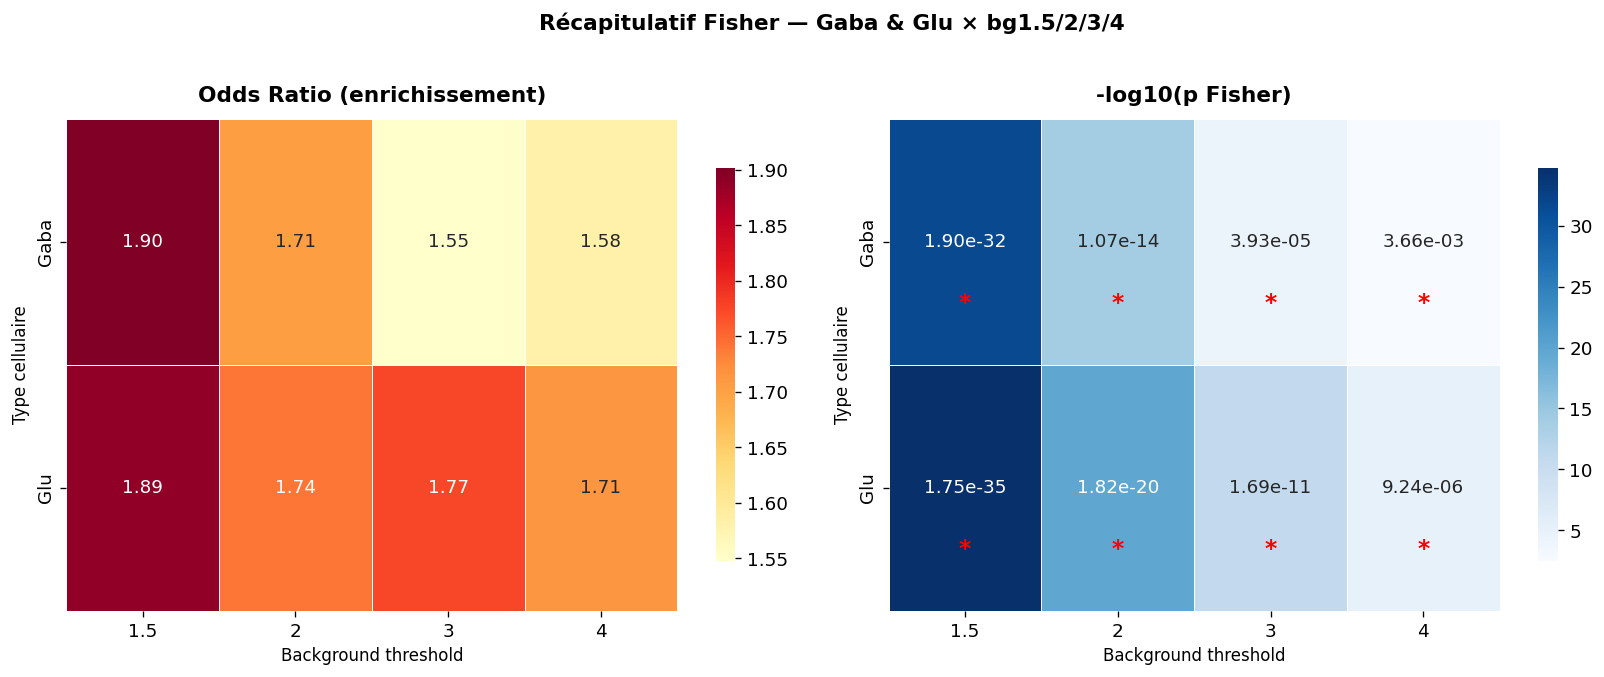

In [10]:
# ── Heatmap récapitulatif : Odds Ratio × (cell type × background) ─────────────
if rows_summary:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax, metric, label, fmt, cmap in [
        (axes[0], "odds_ratio", "Odds Ratio (enrichissement)", ".2f", "YlOrRd"),
        (axes[1], "p_fisher",   "-log10(p Fisher)",            ".2f", "Blues"),
    ]:
        pivot = df_summary.pivot(index="cell_type", columns="bg", values=metric)

        if metric == "p_fisher":
            # Transformer en -log10
            plot_vals = -np.log10(pivot.astype(float).clip(lower=1e-300))
            annot_vals = pivot.applymap(lambda v: f"{v:.2e}")
        else:
            plot_vals  = pivot.astype(float)
            annot_vals = pivot.applymap(lambda v: f"{v:{fmt}}")

        # Masque : cellule grisée si donnée absente
        mask = plot_vals.isna()

        sns.heatmap(
            plot_vals,
            ax=ax,
            cmap=cmap,
            annot=annot_vals,
            fmt="",
            linewidths=0.5,
            mask=mask,
            cbar_kws={"shrink": 0.8},
        )

        # Étoiles significativité sur la heatmap p-value
        if metric == "p_fisher":
            for i, ct in enumerate(pivot.index):
                for j, bg in enumerate(pivot.columns):
                    try:
                        pv = pivot.loc[ct, bg]
                        if not np.isnan(pv) and pv < 0.05:
                            ax.text(j + 0.5, i + 0.75, "*", ha="center",
                                    va="center", fontsize=14, color="red",
                                    fontweight="bold")
                    except Exception:
                        pass

        ax.set_title(label, fontweight="bold", pad=10)
        ax.set_xlabel("Background threshold", fontsize=10)
        ax.set_ylabel("Type cellulaire", fontsize=10)

    plt.suptitle("Récapitulatif Fisher — Gaba & Glu × bg1.5/2/3/4",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    fname = f"{OUT_DIR}/summary_fisher_heatmap.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    print(f"💾 Heatmap sauvegardée : {fname}")
    plt.show()
else:
    print("⚠️  Aucun résultat Fisher disponible pour le récapitulatif.")

In [11]:
# ── Export CSV récapitulatif ──────────────────────────────────────────────────
if rows_summary:
    out_csv = f"{OUT_DIR}/fisher_summary_all.csv"
    df_summary.to_csv(out_csv, index=False)
    print(f"💾 Tableau récapitulatif exporté : {out_csv}")
    display(df_summary)

# ── Export des Golden Genes par combinaison ───────────────────────────────────
golden_rows = []
for ct in CELL_TYPES:
    for bg in BG_THRESHOLDS:
        gd = golden_genes_repo.get(ct, {}).get(bg, {})
        res_de, _, _ = de_results[ct][bg]
        for gene, r_val in gd.items():
            fdr_val = res_de.loc[gene, "fdr"] if gene in res_de.index else float("nan")
            golden_rows.append({
                "cell_type": ct,
                "bg":        bg,
                "gene":      gene,
                "r":         round(r_val, 4),
                "fdr":       fdr_val,
            })

if golden_rows:
    df_golden = pd.DataFrame(golden_rows).sort_values(["cell_type", "bg", "r"])
    out_golden = f"{OUT_DIR}/golden_genes_all.csv"
    df_golden.to_csv(out_golden, index=False)
    print(f"\n💾 Golden Genes exportés : {out_golden}")
    display(df_golden)
else:
    print("⚠️  Aucun Golden Gene à exporter.")

💾 Tableau récapitulatif exporté : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/fisher_summary_all.csv


,cell_type,bg,n_background,n_top_rna,n_atac,overlap,odds_ratio,p_fisher,significant
0,Gaba,1.5,16861,1686,4544,666,1.902,1.896404e-32,True
1,Gaba,2,14663,1466,2273,333,1.705,1.074876e-14,True
2,Gaba,3,10345,1034,841,119,1.547,3.927863e-05,True
3,Gaba,4,5817,581,344,50,1.583,3.658707e-03,True
4,Glu,1.5,17137,1713,6486,888,1.889,1.752777e-35,True
5,Glu,2,14861,1486,3541,503,1.741,1.821725e-20,True
6,Glu,3,10529,1052,1413,215,1.775,1.692621e-11,True
7,Glu,4,5890,589,658,99,1.714,9.238172e-06,True



💾 Golden Genes exportés : /home/boussif/boussif/SEA-AD/MTG_scATAC/data/processed/results_fisher_validation/golden_genes_all.csv


,cell_type,bg,gene,r,fdr
11,Gaba,1.5,RUBCNL,-0.6344,5.333519e-07
13,Gaba,1.5,AC022973.3,-0.6269,6.506108e-07
21,Gaba,1.5,PTPN1,-0.6258,6.506108e-07
29,Gaba,1.5,OSBPL10-AS1,-0.6163,6.506108e-07
8,Gaba,1.5,LINC02144,-0.6133,6.506108e-07
...,...,...,...,...,...
2776,Glu,4,MLLT3,0.5558,7.391794e-06
2782,Glu,4,SNTG1,0.5594,6.688086e-06
2779,Glu,4,YPEL1,0.5650,5.770075e-06
2787,Glu,4,EFNA5,0.5668,5.770075e-06
